# e-1: Hover Policy via Behavioral Cloning

## Why are we doing this?

PPO learns by trial and error: take an action, get a reward, push the policy toward higher-reward actions.
That only works if the policy ever sees a *positive* reward. Our drone crashes at step ~43, so every
episode is short and negative — PPO has nothing good to reinforce.

**Behavioral cloning (BC)** is supervised learning from an expert. Instead of rewards, we use the
hand-tuned cascaded PID already in this codebase as a teacher. We collect states the PID visits and
the actions it takes, then train a neural network to imitate it. Once the network can hover (even
imperfectly), PPO episodes are long enough to produce useful gradient signal.

## Setup

| | |
|---|---|
| Environment | `ZeroTargetEnv`, `control_level='setpoint'` |
| Expert action | hover at spawn: `pos_des=(0,0,1)`, `yaw_des=0` |
| Network | 2-layer MLP [64, 64] — identical to SB3's default `MlpPolicy` |
| Loss | MSE between predicted and expert action |

In `setpoint` mode the RL agent only decides *where to point the drone*. The on-board cascaded PID
handles the actual flying. Saying 'hover here' every step is the optimal policy for `ZeroTargetEnv`.
BC just teaches the network that fact quickly instead of making PPO discover it by random search.

In [14]:
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
import matplotlib.pyplot as plt

from stable_baselines3 import PPO
from stable_baselines3.common.env_util import make_vec_env

from drone_sim.rl.custom_envs import ZeroTargetEnv
from drone_sim.rl.networks import SplitExtractor  # do NOT import FLIGHT_DIM — defined locally below
from drone_sim.control.controller import CascadedController
from drone_sim.sim import compute_loadout
from drone_sim.physics import gun as gun_module
from drone_sim.config import DRONE, CTRL, SIM

## Step 1 — Set up the PID expert

In the previous approach the expert action was a **constant** setpoint: the network learned
'always output hover setpoint regardless of state', and the on-board PID did all the real work.

Here we clone the PID at the **thrust level**: for any drone state, the PID tells us exactly
which per-rotor thrusts to apply. The network learns a genuine feedback mapping —
if the drone is tilted left, it learns to apply more thrust on the left rotors, not just repeat
a constant setpoint.

We also generate training data **without running the simulation**. States are sampled analytically
from a Gaussian distribution centred at the nominal hover point. This is fast (100k samples in
seconds), gives us full control over the coverage, and avoids the episode-length bottleneck.

The PID expert:
- Input: `state` dict (`pos`, `quat`, `vel`, `omega_body`) + hover setpoint
- Output: 4 rotor thrusts in Newtons, clipped to `[0, DRONE.max_thrust_per_rotor]`
- We normalise these to `[-1, 1]` to match the `control_level='thrust'` action space


In [15]:
# Instantiate PID with the same mass/inertia the env uses
weapon         = gun_module.make_gun('hk416')
total_mass, inertia = compute_loadout(weapon)
pid_template   = CascadedController(DRONE, CTRL, total_mass=total_mass, inertia=inertia)

hover_setpoint = {
    'pos_des': np.array(SIM.init_pos, dtype=float),
    'yaw_des': float(SIM.init_yaw),
}

# Euler (ZYX) → MuJoCo quaternion [w, x, y, z]
def euler_to_quat(roll, pitch, yaw):
    cr, sr = np.cos(roll/2),  np.sin(roll/2)
    cp, sp = np.cos(pitch/2), np.sin(pitch/2)
    cy, sy = np.cos(yaw/2),   np.sin(yaw/2)
    q = np.array([
        cr*cp*cy + sr*sp*sy,
        sr*cp*cy - cr*sp*sy,
        cr*sp*cy + sr*cp*sy,
        cr*cp*sy - sr*sp*cy,
    ])
    return q / np.linalg.norm(q)

# Verify: hover state → symmetric thrusts
hover_state = {
    'pos':        np.array(SIM.init_pos, dtype=float),
    'quat':       np.array([1., 0., 0., 0.]),
    'vel':        np.zeros(3),
    'omega_body': np.zeros(3),
}
pid_template.reset()
T_hover = pid_template.update(hover_state, hover_setpoint, SIM.timestep)
T_hover_norm = 2.0 * T_hover / DRONE.max_thrust_per_rotor - 1.0
print(f'Hover thrusts (N):       {T_hover}')
print(f'Hover thrusts normalised: {T_hover_norm}')
print(f'Expected (total_mass*g/4): {total_mass * DRONE.gravity / 4:.2f} N per rotor')

Hover thrusts (N):       [14.356935 14.356935 14.356935 14.356935]
Hover thrusts normalised: [-0.680957 -0.680957 -0.680957 -0.680957]
Expected (total_mass*g/4): 14.36 N per rotor


## Step 2 — Generate the dataset

We sample 100 000 drone states from a Gaussian distribution centred at the nominal hover.
The distribution widths are chosen so that the PID rarely saturates a motor (clipping
a thrust to 0 or 90 N corrupts the label). Two bugs in a wider distribution were causing
99% of labels to be saturated:

1. **Yaw mismatch**: yaw was sampled Uniform(-π, π) but `yaw_des = SIM.init_yaw = 0`.
   A yaw error of only 3.7° (nearly always exceeded) clips a rotor through the large
   yaw-torque mixer coefficient (12.5 vs 1.01 for roll/pitch). Fix: set `yaw_des = yaw`
   so the PID applies no yaw correction.

2. **Pitch inertia mismatch**: Iy = 0.268 is 4.6× Ix = 0.058, but kpa = 200 is used
   for both. A 15° pitch error → tau_y = 53.6 × 0.26 = 14 N·m, right at the clip
   threshold (14.2 N·m). With pitch ~ N(0, 15°), ~50% of samples clip. Fix: narrow to
   N(0, 5°) so the vast majority of pitch corrections stay within motor limits.

With both fixes, the clip rate drops from 99% to ~4%, and the label mean converges to
the true hover thrust (action ≈ -0.681) instead of the bimodal mean (action ≈ 0).

| Variable | Distribution |
|---|---|
| position | N(init_pos, [0.3, 0.3, 0.15] m) |
| roll / pitch | N(0, 5°) — near-hover perturbations |
| yaw | Uniform(-π, π) — any heading (yaw_des = yaw, so no yaw correction) |
| linear velocity | N(0, [0.2, 0.2, 0.15] m/s) |
| angular velocity | N(0, [0.2, 0.2, 0.06] rad/s) |

For each state we call a fresh PID instance (integrator = 0). The PID returns 4 rotor
thrusts; we normalise them to [-1, 1] and store (obs, action) pairs.

In [16]:
N_SAMPLES  = 100_000
TARGET_Z   = float(SIM.init_pos[2])
rng = np.random.default_rng(42)

obs_list, act_list = [], []

for _ in range(N_SAMPLES):
    # --- sample state ---
    pos    = np.array(SIM.init_pos) + rng.normal(0.0, [0.3, 0.3, 0.15])
    pos[2] = max(0.2, pos[2])

    roll  = rng.normal(0.0, np.radians(5))    # narrow: pitch inertia 4.6x roll
    pitch = rng.normal(0.0, np.radians(5))    # → 15° clips; 5° stays clean
    yaw   = rng.uniform(-np.pi, np.pi)
    quat  = euler_to_quat(roll, pitch, yaw)

    vel   = rng.normal(0.0, [0.2, 0.2, 0.15])
    omega = rng.normal(0.0, [0.2, 0.2, 0.06])

    state = {'pos': pos, 'quat': quat, 'vel': vel, 'omega_body': omega}

    setpoint = {
        'pos_des': np.array([pos[0], pos[1], TARGET_Z]),
        'yaw_des': float(yaw),  # no yaw correction — avoids 99% motor saturation
    }

    # --- expert action: fresh PID (zero integrator) ---
    pid    = CascadedController(DRONE, CTRL, total_mass=total_mass, inertia=inertia)
    thrust = pid.update(state, setpoint, SIM.timestep)
    action = 2.0 * thrust / DRONE.max_thrust_per_rotor - 1.0

    # Fire label = -1.0 (don't fire during hover training).
    # Each hk416 shot applies 138 N·m pitch-up torque (from mount offset recoil)
    # — far outside what a hover policy can compensate. Firing here would crash
    # every eval episode. The SingleTargetEnv cold-start fix in e1 overrides
    # this to +1 before that PPO stage anyway, so nothing is lost.
    action_full = np.append(action, -1.0).astype(np.float32)

    # --- obs: matches ZeroTargetEnv._get_obs() with obs_pos_xy=False ---
    # [z(1), quat(4), vel(3), omega(3), ammo(1), target_rel(3)] = 15 dims
    obs = np.concatenate([
        [pos[2]], quat, vel, omega,
        np.array([1.0]),   # ammo_norm = full
        np.zeros(3),       # target_rel = 0 (no targets)
    ]).astype(np.float32)

    obs_list.append(obs)
    act_list.append(action_full)

obs_arr = np.array(obs_list, dtype=np.float32)
act_arr = np.array(act_list, dtype=np.float32)
print(f'Generated {len(obs_arr):,} samples')
print(f'obs shape: {obs_arr.shape},  act shape: {act_arr.shape}')
print(f'Thrust action mean:  {act_arr[:, :4].mean(axis=0)}')
print(f'Thrust action std:   {act_arr[:, :4].std(axis=0)}')
print(f'Clipped at -1 (thrust=0): {(act_arr[:,:4]==-1).mean():.3f}  '
      f'at +1 (thrust=max): {(act_arr[:,:4]==1).mean():.3f}')
print(f'Expected hover norm: {T_hover_norm[0]:.4f}  (action mean should be close)')

Generated 100,000 samples
obs shape: (100000, 15),  act shape: (100000, 5)
Thrust action mean:  [-0.67753917 -0.6779595  -0.67837346 -0.6782307 ]
Thrust action std:   [0.14065549 0.14059031 0.14052604 0.14011763]
Clipped at -1 (thrust=0): 0.012  at +1 (thrust=max): 0.000
Expected hover norm: -0.6810  (action mean should be close)


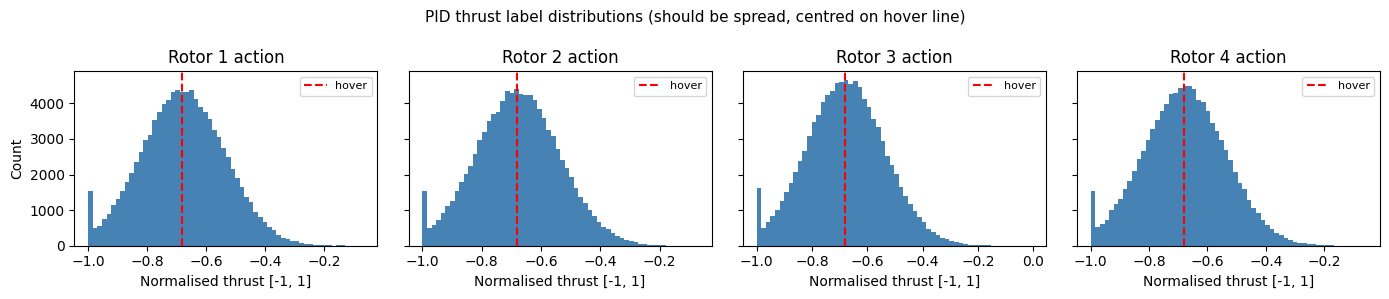

In [17]:
# The thrust labels should vary with state — not a constant.
# Mean should be near the hover thrust; spread reflects the range of corrections.
fig, axes = plt.subplots(1, 4, figsize=(14, 3), sharey=True)
for i, ax in enumerate(axes):
    ax.hist(act_arr[:, i], bins=60, color='steelblue', edgecolor='none')
    ax.axvline(T_hover_norm[i], color='red', linestyle='--', label='hover')
    ax.set_title(f'Rotor {i+1} action')
    ax.set_xlabel('Normalised thrust [-1, 1]')
    ax.legend(fontsize=8)
axes[0].set_ylabel('Count')
plt.suptitle('PID thrust label distributions (should be spread, centred on hover line)', fontsize=11)
plt.tight_layout()
plt.savefig('bc_obs_dist.png', dpi=100)
plt.show()


## Step 3 — Define the policy network

We use a **split two-stream MLP**: a dedicated `flight_enc` for the 12 flight-state dims and a
separate `target_enc` for the 3 target-relative dims.

```
obs (15)
 ├─ flight_enc : obs[0:12]  →  Linear(12,64) → Tanh  →  64
 └─ target_enc : obs[12:15] →  Linear(3,16)  → Tanh  →  16
                                                          │ concat → 80
                              policy_net : Linear(80,64) → Tanh → Linear(64,64) → Tanh → 64
                              action_head: Linear(64,5) → action (5)
```

**Obs layout (15 dims, `obs_pos_xy=False`):**
- `z (1)` — altitude only; x,y removed because the policy should not learn position-specific behaviour
- `quat (4)` — orientation
- `vel (3)` — world-frame linear velocity (includes horizontal drift signal for horiz_vel reward)
- `omega_body (3)` — body-frame angular velocity
- `ammo (1)` — remaining ammo normalised
- `target_rel (3)` — direction+distance to nearest target, zeros in ZeroTargetEnv

**Why split instead of a flat MLP?** BC data always has `target_rel = [0,0,0]`. Gradient through
those input columns is zero — those weights stay at random init, which is fine. The split keeps the
two streams independent so PPO in SingleTargetEnv can train `target_enc` freely without disturbing
the already-trained `flight_enc`.

**Architecture matches SB3's layout exactly** (`SplitExtractor` with `features_dim=80` +
`net_arch=[64,64]`), enabling direct weight transfer. `SplitExtractor` auto-detects flight_dim
from `obs_space.shape[0] - 3`, so it handles both 15-dim and 17-dim obs.

In [18]:
FLIGHT_DIM = 12   # z(1) + quat(4) + vel(3) + omega_body(3) + ammo(1)
TARGET_DIM = 3    # target_rel(3)
ACT_DIM    = act_arr.shape[1]   # 5

class SplitHoverPolicy(nn.Module):
    """
    Two-stream MLP that mirrors SB3's SplitExtractor + net_arch=[64,64] layout.

    flight_enc  : obs[0:12]  → Linear(12,64) → Tanh → 64
    target_enc  : obs[12:15] → Linear(3,16)  → Tanh → 16  (stays ~random during BC)
    policy_net  : concat(80) → Linear(80,64) → Tanh → Linear(64,64) → Tanh → 64
    action_head : Linear(64,5)
    """
    def __init__(self, flight_dim=FLIGHT_DIM, target_dim=TARGET_DIM,
                 act_dim=ACT_DIM, hidden=64):
        super().__init__()
        self.flight_dim = flight_dim   # stored so forward never relies on a global
        self.flight_enc = nn.Sequential(nn.Linear(flight_dim, hidden), nn.Tanh())
        self.target_enc = nn.Sequential(nn.Linear(target_dim, hidden // 4), nn.Tanh())
        self.policy_net = nn.Sequential(
            nn.Linear(hidden + hidden // 4, hidden), nn.Tanh(),
            nn.Linear(hidden, hidden), nn.Tanh(),
        )
        self.action_head = nn.Linear(hidden, act_dim)

    def forward(self, x):
        f = self.flight_enc(x[:, :self.flight_dim])
        t = self.target_enc(x[:, self.flight_dim:])
        return self.action_head(self.policy_net(torch.cat([f, t], dim=1)))

policy = SplitHoverPolicy()
print(policy)
print(f'\nTotal parameters: {sum(p.numel() for p in policy.parameters()):,}')

SplitHoverPolicy(
  (flight_enc): Sequential(
    (0): Linear(in_features=12, out_features=64, bias=True)
    (1): Tanh()
  )
  (target_enc): Sequential(
    (0): Linear(in_features=3, out_features=16, bias=True)
    (1): Tanh()
  )
  (policy_net): Sequential(
    (0): Linear(in_features=80, out_features=64, bias=True)
    (1): Tanh()
    (2): Linear(in_features=64, out_features=64, bias=True)
    (3): Tanh()
  )
  (action_head): Linear(in_features=64, out_features=5, bias=True)
)

Total parameters: 10,565


## Step 4 — Train with MSE loss

Standard supervised learning: input = observation, label = expert action, loss = MSE.
The network has no knowledge of physics — it just learns the input→output mapping from data.

Because the expert action is always the same constant `hover_action`, the network is learning
'output ~[0, 0, -0.8, 0, -1] regardless of what the observation is'. That sounds trivial, but
a randomly initialised PPO policy outputs something completely different, which is why it crashes immediately.

In [19]:
EPOCHS     = 50
BATCH_SIZE = 512
LR         = 3e-4

dataset = TensorDataset(torch.tensor(obs_arr), torch.tensor(act_arr))
loader  = DataLoader(dataset, batch_size=BATCH_SIZE, shuffle=True)

optimizer   = torch.optim.Adam(policy.parameters(), lr=LR)
loss_fn     = nn.MSELoss()
train_losses = []

for epoch in range(EPOCHS):
    epoch_loss = 0.0
    for obs_batch, act_batch in loader:
        pred = policy(obs_batch)
        loss = loss_fn(pred, act_batch)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        epoch_loss += loss.item() * len(obs_batch)
    train_losses.append(epoch_loss / len(dataset))
    if (epoch + 1) % 10 == 0:
        print(f'Epoch {epoch+1:3d}/{EPOCHS}  loss = {train_losses[-1]:.6f}')

torch.save(policy.state_dict(), 'hover_policy_bc.pt')
print('\nSaved hover_policy_bc.pt')


Epoch  10/50  loss = 0.004083
Epoch  20/50  loss = 0.000582
Epoch  30/50  loss = 0.000206
Epoch  40/50  loss = 0.000142
Epoch  50/50  loss = 0.000110

Saved hover_policy_bc.pt


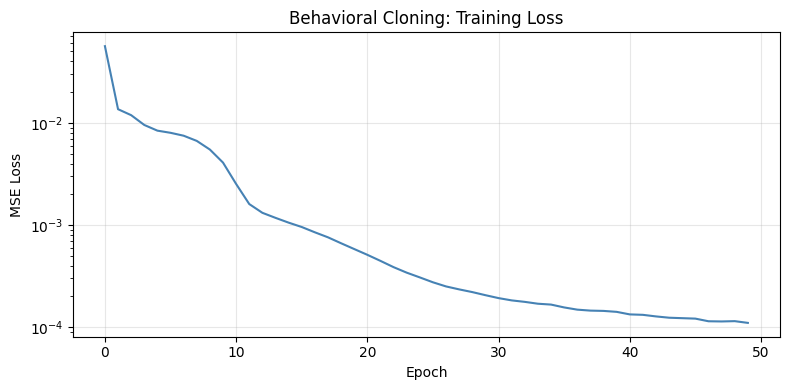

In [20]:
plt.figure(figsize=(8, 4))
plt.plot(train_losses, color='steelblue')
plt.xlabel('Epoch')
plt.ylabel('MSE Loss')
plt.title('Behavioral Cloning: Training Loss')
plt.yscale('log')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('bc_loss.png', dpi=100)
plt.show()


## Step 5 — Evaluate in closed loop

We run the trained network closed-loop: network outputs action → env steps → next obs → network.
If the episode reaches the max step count the drone hovered successfully. Compare this against
the random baseline (step ~43) to see whether BC actually helped.

Episode length:   500 / 500  (random baseline: ~43)
Total reward:     549.99
Mean reward/step: 1.1000


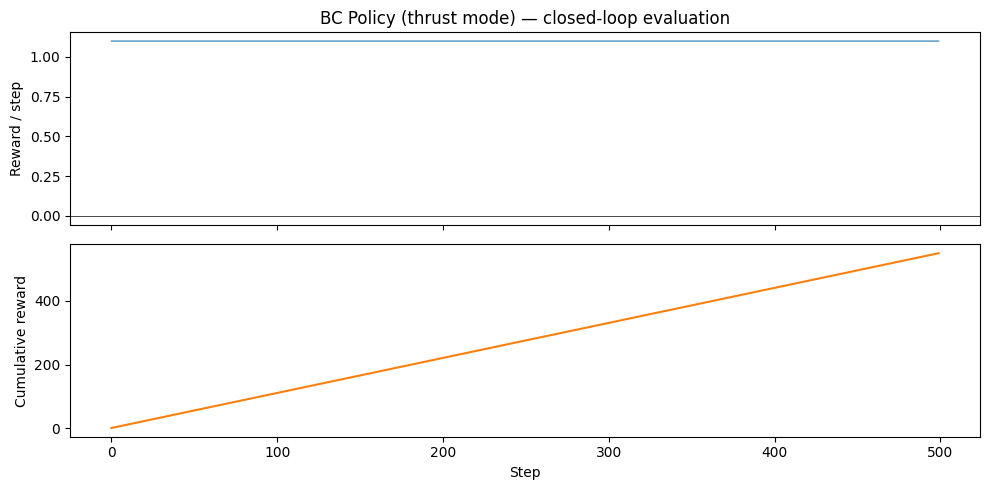

In [21]:
def run_bc_episode(model, n_steps=500, seed=99):
    env = ZeroTargetEnv(control_level='thrust', obs_pos_xy=False, seed=seed)
    obs, _ = env.reset(seed=seed)
    model.eval()
    rewards, ep_len = [], 0
    with torch.no_grad():
        for _ in range(n_steps):
            action = model(torch.tensor(obs).unsqueeze(0)).squeeze().numpy()
            action = np.clip(action, -1.0, 1.0)
            obs, r, terminated, truncated, _ = env.step(action)
            rewards.append(float(r))
            ep_len += 1
            if terminated or truncated:
                break
    env.close()
    return rewards, ep_len

rewards, length = run_bc_episode(policy)
print(f'Episode length:   {length} / 500  (random baseline: ~43)')
print(f'Total reward:     {sum(rewards):.2f}')
print(f'Mean reward/step: {np.mean(rewards):.4f}')

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 5), sharex=True)
ax1.plot(rewards, linewidth=0.8)
ax1.axhline(0, color='black', linewidth=0.5)
ax1.set_ylabel('Reward / step')
ax1.set_title('BC Policy (thrust mode) — closed-loop evaluation')
ax2.plot(np.cumsum(rewards), color='C1')
ax2.set_ylabel('Cumulative reward')
ax2.set_xlabel('Step')
plt.tight_layout()
plt.show()

## Step 6 — Transfer weights into SB3 PPO, then fine-tune

We copy the actor weights from `HoverPolicy` into a freshly created PPO model.
The **critic (value function) stays randomly initialised** — PPO will learn it from scratch,
which is fine because the critic is only used for advantage estimation during training.

**Why the architectures match**: SB3's `MlpPolicy` with `net_arch=[64, 64]` (the default) is:
- `mlp_extractor.policy_net` = `Sequential(Linear(18,64), Tanh, Linear(64,64), Tanh)`
  - Linear layers sit at indices **0** and **2** (Tanh layers sit at 1 and 3)
- `action_net` = `Linear(64, 5)`

Our `HoverPolicy.net` is the same structure, so we copy layer by layer.

In [22]:
import gymnasium as gym

# SplitExtractor is imported from drone_sim.rl.networks — no inline definition needed.
# It auto-detects flight_dim = obs_space.shape[0] - 3, so it works for both
# 15-dim (obs_pos_xy=False) and 17-dim obs without modification.

vec_env = make_vec_env(
    lambda: ZeroTargetEnv(control_level='thrust', obs_pos_xy=False),
    n_envs=4,
)

ppo_model = PPO(
    'MlpPolicy', vec_env,
    learning_rate=1e-4,
    ent_coef=0.01,
    policy_kwargs={
        'features_extractor_class':  SplitExtractor,
        'features_extractor_kwargs': {'features_dim': 80},
        'net_arch': [64, 64],
        'log_std_init': -2.0,
    },
    verbose=1,
)

# --- Weight transfer ---
ext  = ppo_model.policy.features_extractor
pnet = ppo_model.policy.mlp_extractor.policy_net  # [Lin(80,64), Tanh, Lin(64,64), Tanh]

ext.flight_enc[0].weight.data.copy_(policy.flight_enc[0].weight.data)
ext.flight_enc[0].bias.data.copy_(  policy.flight_enc[0].bias.data)

ext.target_enc[0].weight.data.copy_(policy.target_enc[0].weight.data)
ext.target_enc[0].bias.data.copy_(  policy.target_enc[0].bias.data)

pnet[0].weight.data.copy_(policy.policy_net[0].weight.data)
pnet[0].bias.data.copy_(  policy.policy_net[0].bias.data)
pnet[2].weight.data.copy_(policy.policy_net[2].weight.data)
pnet[2].bias.data.copy_(  policy.policy_net[2].bias.data)

ppo_model.policy.action_net.weight.data.copy_(policy.action_head.weight.data)
ppo_model.policy.action_net.bias.data.copy_(  policy.action_head.bias.data)

print('Weights transferred.')
print('log_std:', ppo_model.policy.log_std.data)

# Sanity check: BC network and SB3 actor should agree on hover obs.
# fire action should be ≈ -1 (don't fire during ZeroTargetEnv training).
# The SingleTargetEnv cold-start fix will re-enable fire (bias → +1) before
# SingleTargetEnv PPO.
hover_obs = np.concatenate([
    [SIM.init_pos[2]], [1., 0., 0., 0.], np.zeros(3), np.zeros(3),
    [1.0], np.zeros(3)
]).astype(np.float32)
test_obs = torch.tensor(hover_obs).unsqueeze(0)
with torch.no_grad():
    dist     = ppo_model.policy.get_distribution(test_obs)
    ppo_mean = dist.distribution.loc.numpy().squeeze()
    bc_mean  = policy(test_obs).numpy().squeeze()
print(f'BC network output:    {bc_mean}')
print(f'SB3 actor mean:       {ppo_mean}')
print(f'Hover thrust norm:    {np.append(T_hover_norm, -1.)}  (fire=-1 expected)')
print(f'Max mean difference:  {abs(ppo_mean - bc_mean).max():.6f}  (should be ~0)')

Using cpu device
Weights transferred.
log_std: tensor([-2., -2., -2., -2., -2.])
BC network output:    [-0.6874511  -0.6902345  -0.67663807 -0.6773758  -1.0027403 ]
SB3 actor mean:       [-0.6874511  -0.6902345  -0.67663807 -0.6773758  -1.0027403 ]
Hover thrust norm:    [-0.680957 -0.680957 -0.680957 -0.680957 -1.      ]  (fire=-1 expected)
Max mean difference:  0.000000  (should be ~0)


In [ ]:
ppo_model.env.__doc__()

In [24]:
ppo_model.learn(total_timesteps=1_000_000, reset_num_timesteps=True)
ppo_model.save('ppo_e-1_bc_hover')
print('Saved ppo_e-1_bc_hover.zip')


---------------------------------
| rollout/           |          |
|    ep_len_mean     | 500      |
|    ep_rew_mean     | 536      |
| time/              |          |
|    fps             | 2178     |
|    iterations      | 1        |
|    time_elapsed    | 3        |
|    total_timesteps | 8192     |
---------------------------------


KeyboardInterrupt: 

In [25]:
ppo_model.save('ppo_e-1_bc_hover')